# TELL Load Forecast Data Flow And 2023 Validation

This notebook demonstrates the TELL load-modeling workflow for `MISO`. The model is calibrated and trained on 2019–2022 EIA-930 actual load aligned in UTC with historical BA weather and calendar variables, validated against held-out 2023 load, and then applied to weather years 2007–2023.

The notebook is organized into four parts:

1. **Data Preparation And Cleaning — Steps 1–5:** Select the BA, clean the EIA-930 actual load, construct the weather and calendar predictor variables, and write `56669_training.csv`. This CSV is required by TELL's file-based `train()` interface for both calibration and final training; it is not needed later to apply an already-trained model.
2. **Model Calibration And Training — Steps 6–8:** Compare candidate multilayer perceptron (MLP) configurations, record their validation results in `MISO_mlp_tuning.csv`, select the best configuration, and train the final model. Step 8 saves two reusable `.joblib` files: the fitted scikit-learn MLP and the normalization dictionary used to scale its inputs and convert its predictions back to MW. Both files are required for prediction; the tuning CSV documents model selection but is not a prediction input.
3. **Model Prediction — Steps 9–10:** Write one `{BA_ID}_weather_{year}.csv` file per target weather year. Each file contains the same predictor columns used for training. TELL's `predict()` function reads these yearly files together with both `.joblib` files and produces the hourly 2007–2023 load forecast.
4. **Model Validation — Step 11:** Compare the held-out 2023 forecast with EIA-930 actual load and write the validation CSV, summary metrics, actual-versus-forecast scatter plot, and January time-series plot.

The trained model can also be applied to sup3rCC weather without retraining. Historical weather is needed for model training because every hourly predictor row must align with the corresponding hourly EIA-930 load observation. To apply the resulting model to sup3rCC, transform the sup3rCC weather into the identical predictor columns constructed in Step 4, write the yearly prediction-weather CSVs in the Step 9 format, and call `predict()` as shown in Step 10 using the MLP and normalization `.joblib` files saved in Step 8.

## Imports And Paths

Load the libraries used below and point directly to the packaged data and notebook scratch-output folders.


In [1]:
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pandas.tseries.holiday import USFederalHolidayCalendar

DATA_ROOT = Path("../../data")
OUTPUT_DIR = Path("../../notebook_outputs/data_flow/tell_load_forecast_data_flow")

if not DATA_ROOT.is_dir():
    raise FileNotFoundError(
        "Expected to find the packaged data folder at ../data. "
        "Open this notebook from inside notebooks/data_flow."
    )

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


## Step 1: Select BA Metadata

This step selects the `BA_CODE` (`MISO` in this example) and reads the packaged BA metadata (`BA_ID` and `BA_NAME`). Note that TELL uses the EIA balancing-authority number (`BA_ID`) as its region identifier.


In [2]:
BA_CODE = "MISO"

ba_metadata = pd.read_csv(DATA_ROOT / "validation" / "load_forecast" / "ba_2023_validation_metadata.csv", dtype={"BA_CODE": str, "BA_ID": str},)
ba_row = ba_metadata.loc[ba_metadata["BA_CODE"].eq(BA_CODE)].iloc[0]
BA_ID = str(ba_row["BA_ID"])

pd.DataFrame([
    {"setting": "BA_CODE", "value": BA_CODE},
    {"setting": "BA_ID", "value": BA_ID},
    {"setting": "BA_NAME", "value": str(ba_row["BA_NAME"])},
])

,setting,value
0,BA_CODE,MISO
1,BA_ID,56669
2,BA_NAME,"Midcontinent Independent System Operator, Inc."


## Step 2: Load Raw EIA-930 Actual Load

EIA-930 actual-load data is packaged under `data/load_actuals/raw`.


In [3]:
raw_actual_csv = DATA_ROOT / "load_actuals" / "raw" / f"{BA_CODE}_hourly_load.csv"

# Read raw EIA-930 actual load so the cleaning method can be reviewed.
raw_actual = pd.read_csv(raw_actual_csv, usecols=["Time_UTC", "Load"])
raw_actual = raw_actual.rename(columns={"Time_UTC": "time_utc", "Load": "load_actual_mw_raw"})
raw_actual["time_utc"] = pd.to_datetime(raw_actual["time_utc"], utc=True)
raw_actual["load_actual_mw_raw"] = pd.to_numeric(raw_actual["load_actual_mw_raw"])

display(raw_actual.head())
display(pd.DataFrame([{"series": "raw actual load", "rows": len(raw_actual), "path": str(raw_actual_csv.relative_to(Path('../..')))},]))

,time_utc,load_actual_mw_raw
0,2019-01-01 00:00:00+00:00,74304.0
1,2019-01-01 01:00:00+00:00,73391.0
2,2019-01-01 02:00:00+00:00,71531.0
3,2019-01-01 03:00:00+00:00,69562.0
4,2019-01-01 04:00:00+00:00,67744.0


,series,rows,path
0,raw actual load,43824,data\load_actuals\raw\MISO_hourly_lo...


## Step 3: Clean Missing, Nonpositive, And Same-Hour Outlier Load

This step applies the cleaning logic to the raw EIA-930 input and creates `cleaned_actuals`, the table used below for TELL training and 2023 validation. This cleaning step applies two rules:

1. Invalid load rule: missing, zero, or negative load is set to missing.
2. Same-hour outlier rule: each load value is compared with a centered 7-day rolling median for the same local clock hour. The median is calculated when at least five valid same-hour observations are available. Values differing from this median by 40% or more are removed.

After cleaning, the notebook keeps the 2019-2023 rows used for 2019-2022 model training and 2023 model validation.

In [4]:
DEVELOPMENT_YEARS = [2019, 2020, 2021, 2022]
VALIDATION_YEAR = 2023
LOCAL_TIMEZONE = "America/Chicago"

load_cleaning = raw_actual.sort_values("time_utc").reset_index(drop=True)
load_cleaning["year"] = load_cleaning["time_utc"].dt.year
load_cleaning["local_clock_hour"] = load_cleaning["time_utc"].dt.tz_convert(LOCAL_TIMEZONE).dt.hour

# Rule 1: remove missing, zero, or negative load.
load_cleaning["load_flag_missing_nonpositive"] = load_cleaning["load_actual_mw_raw"].isna() | load_cleaning["load_actual_mw_raw"].le(0)
load_cleaning["load_actual_mw_clean"] = load_cleaning["load_actual_mw_raw"].mask(load_cleaning["load_flag_missing_nonpositive"])

##### Rule 2
# baseline: calculate rolling median of nearby days at the same local clock hour.
load_cleaning["same_hour_median_baseline_mw"] = np.nan
for clock_hour in range(24):
    same_hour_rows = load_cleaning["local_clock_hour"].eq(clock_hour)
    load_cleaning.loc[same_hour_rows, "same_hour_median_baseline_mw"] = load_cleaning.loc[same_hour_rows, "load_actual_mw_clean"].rolling(window=7, center=True, min_periods=5).median()

# remove values at least 40 percent away from the baseline.
pct_diff_from_baseline = (load_cleaning["load_actual_mw_clean"] - load_cleaning["same_hour_median_baseline_mw"]).abs() / load_cleaning["same_hour_median_baseline_mw"].abs()
load_cleaning["load_flag_same_hour_outlier"] = pct_diff_from_baseline.ge(0.40).fillna(False)
load_cleaning["load_actual_mw_clean"] = load_cleaning["load_actual_mw_clean"].mask(load_cleaning["load_flag_same_hour_outlier"])
##### End Rule 2

# Keep the actual-load years used for TELL training and held-out validation.
cleaned_actual_columns = ["time_utc", "year", "load_actual_mw_clean"]
cleaned_actuals = load_cleaning.loc[load_cleaning["year"].isin(DEVELOPMENT_YEARS + [VALIDATION_YEAR]), cleaned_actual_columns].reset_index(drop=True)

cleaning_summary = pd.DataFrame([
    {"cleaning_step": "raw rows", "count": len(load_cleaning)},
    {"cleaning_step": "missing or nonpositive load values", "count": int(load_cleaning["load_flag_missing_nonpositive"].sum())},
    {"cleaning_step": "same-hour 40 pct outliers", "count": int(load_cleaning["load_flag_same_hour_outlier"].sum())},
    {"cleaning_step": "remaining missing cleaned load", "count": int(cleaned_actuals["load_actual_mw_clean"].isna().sum())},
    {"cleaning_step": "non-Nan cleaned load values", "count": int(cleaned_actuals["load_actual_mw_clean"].notna().sum()),
}
])
display(cleaning_summary)


,cleaning_step,count
0,raw rows,43824
1,missing or nonpositive load values,11
2,same-hour 40 pct outliers,0
3,remaining missing cleaned load,11
4,non-Nan cleaned load values,43813


## Step 4: Build Weather And Calendar Predictors

The below table shows the predictor variables, organized by category. 


| Predictor group | Raw input column(s) | Model feature column(s) |
|---|---|---|
| direct weather predictors | packaged BA-weather columns | `temperature_2m`, `windspeed_10m`, `ghi` |
| annual BA population | optional table with `Year` and `Population` | `Population` (not activated in this demonstration) |
| local daily cycle | `time_utc` converted to local hour | `Hour_sin`, `Hour_cos` |
| local seasonal cycle | `time_utc` converted to local day of year | `DOY_sin`, `DOY_cos` |
| local weekly cycle | `time_utc` converted to local day of week | `DOW_sin`, `DOW_cos` |
| federal holiday | local date | `IsHoliday` |
| degree response | `temperature_2m` | `CoolDegC`, `HeatDegC` |
| temperature memory | `temperature_2m` grouped by `load_weather_source` | `temperature_2m_roll_mean_24h`, `temperature_2m_roll_mean_72h` |
| temp * humidity (heat index proxy) | `temperature_2m`, `specifichumidity_2m` | not used in the current predictor list |


*Notes*:

-  Rolling temperature predictors carry across years within the same `load_weather_source` and reset when `load_weather_source` changes. For this example, they carry across 2007-2014 for `wtk_nsrdb`, then reset at the start of 2015 for `bchrrr_nsrdb`.

-  Although TELL can use annual population as a predictor,  population is not activated in this demonstration because the available population assumption is constant across the training period. To use historical or projected population, merge a `Year`-`Population` table at the indicated point in the code and add `Population` to `PREDICTOR_COLUMNS`. It will then flow automatically into both the Step 5 training CSV and the Step 9 prediction-weather CSVs.

-  There are some faulty relative humidity values in the official WTK dataset, including values over 600% during summer 2012. For this reason, specific_humidity_2m` and the temperature-humidity interaction term (the "heat index proxy) from this predictor set because they produced unrealistically high modeled loads.

In [5]:
SOURCE_BUNDLE = "wtk_bchrrr_nsrdb"   # use temperature_2m and windspeed_10m from WTK/BC-HRRR; use ghi from NSRDB
PERIOD_LABEL = "2007_2023"

PREDICTOR_COLUMNS = [
    # Direct weather variables from BCHRRR/WTK/NSRDB.
    "temperature_2m",       # air temperature
    "windspeed_10m",        # wind speed
    "ghi",                  # sunlight/irradiance
    # "Population",           # enable when a time-varying population series is supplied

    # Local-time calendar variables.
    "Hour_sin",             # hour of day cycle
    "Hour_cos",             # hour of day cycle
    "DOY_sin",              # day of year cycle
    "DOY_cos",              # day of year cycle
    "DOW_sin",              # day of week cycle
    "DOW_cos",              # day of week cycle
    "IsHoliday",            # federal holiday flag

    # Derived weather variables used by the archived TELL workflow.
    "CoolDegC",             # cooling-degree response above 18 C
    "HeatDegC",             # heating-degree response below 18 C
    "temperature_2m_roll_mean_24h",          # 24-hour rolling temperature mean
    "temperature_2m_roll_mean_72h",          # 72-hour rolling temperature mean
]

source_periods_csv = DATA_ROOT / "model_parameters" / f"load_weather_source_periods_{PERIOD_LABEL}.csv"
weather_csv = DATA_ROOT / f"{SOURCE_BUNDLE}_{PERIOD_LABEL}" / "ba_weather" / f"{BA_CODE}_{SOURCE_BUNDLE}_{PERIOD_LABEL}_weather.csv"

# Read the weather-source period table that documents the combined weather bundle.
source_periods = pd.read_csv(source_periods_csv)
source_periods = source_periods.loc[source_periods["source_bundle"].eq(SOURCE_BUNDLE)]
display(source_periods)

# Read only the packaged BA-weather columns used by the model.
feature_variables = pd.read_csv(weather_csv, usecols=["time_utc", "temperature_2m", "windspeed_10m", "ghi"]).rename(columns={"time_utc": "Time_UTC"})
feature_variables["Time_UTC"] = pd.to_datetime(feature_variables["Time_UTC"], utc=True)
feature_variables = feature_variables.sort_values("Time_UTC").reset_index(drop=True)
feature_variables["year"] = feature_variables["Time_UTC"].dt.year

# Assign each weather row to the load-weather-source period documented above.
feature_variables["load_weather_source"] = pd.NA
for _, source_period in source_periods.iterrows():
    years_in_period = feature_variables["year"].between(int(source_period["start_year"]), int(source_period["end_year"]))
    feature_variables.loc[years_in_period, "load_weather_source"] = source_period["load_weather_source"]

if feature_variables["load_weather_source"].isna().any():
    raise ValueError("Some weather rows were not assigned to a documented load_weather_source weather-source period.")

# Add UTC fields for joins and local fields for TELL-style calendar predictors.
stamp_utc = feature_variables["Time_UTC"]
stamp_local = stamp_utc.dt.tz_convert(LOCAL_TIMEZONE)
feature_variables["Year"] = stamp_local.dt.year
feature_variables["Month"] = stamp_local.dt.month
feature_variables["Day"] = stamp_local.dt.day
feature_variables["Hour"] = stamp_local.dt.hour

# Optional annual population predictor.
# `population_by_year` must contain one row per local year with: Year, Population.
# feature_variables = feature_variables.merge(population_by_year, on="Year", how="left", validate="many_to_one")

# Add daily, seasonal, and weekly cycles.
hour = stamp_local.dt.hour.astype(float)
day_of_year = stamp_local.dt.dayofyear.astype(float)
day_of_week = stamp_local.dt.dayofweek.astype(float)
feature_variables["Hour_sin"] = np.sin(2.0 * np.pi * hour / 24.0)
feature_variables["Hour_cos"] = np.cos(2.0 * np.pi * hour / 24.0)
feature_variables["DOY_sin"] = np.sin(2.0 * np.pi * day_of_year / 365.25)
feature_variables["DOY_cos"] = np.cos(2.0 * np.pi * day_of_year / 365.25)
feature_variables["DOW_sin"] = np.sin(2.0 * np.pi * day_of_week / 7.0)
feature_variables["DOW_cos"] = np.cos(2.0 * np.pi * day_of_week / 7.0)

# Add holiday and non-rolling weather predictors.
holidays = USFederalHolidayCalendar().holidays(start=stamp_local.min().normalize(), end=stamp_local.max().normalize())
feature_variables["IsHoliday"] = stamp_local.dt.normalize().isin(holidays).astype(int)
feature_variables["CoolDegC"] = (feature_variables["temperature_2m"] - 18.0).clip(lower=0.0)
feature_variables["HeatDegC"] = (18.0 - feature_variables["temperature_2m"]).clip(lower=0.0)

# Rolling means carry across years within a weather source, but reset when load_weather_source changes.
temperature_by_source = feature_variables.groupby("load_weather_source", sort=False)["temperature_2m"]
for hours in (24, 72):
    feature_variables[f"temperature_2m_roll_mean_{hours}h"] = temperature_by_source.transform(lambda values: values.rolling(hours, min_periods=1).mean())
display(feature_variables[["Time_UTC", "load_weather_source"] + PREDICTOR_COLUMNS].head())


,source_bundle,source_window_index,start_year,end_year,load_weather_source,wind_source,solar_source
0,wtk_bchrrr_nsrdb,1,2007,2014,wtk_nsrdb,wtk,nsrdb
1,wtk_bchrrr_nsrdb,2,2015,2023,bchrrr_nsrdb,bchrrr,nsrdb


,Time_UTC,load_weather_source,temperature_2m,windspeed_10m,ghi,Hour_sin,Hour_cos,DOY_sin,DOY_cos,DOW_sin,DOW_cos,IsHoliday,CoolDegC,HeatDegC,temperature_2m_roll_mean_24h,temperature_2m_roll_mean_72h
0,2007-01-01 00:00:00+00:00,wtk_nsrdb,6.888647,4.261637,0.0,-1.000000,-1.836970e-16,-0.004301,0.999991,-0.781831,0.62349,0,0.0,11.111353,6.888647,6.888647
1,2007-01-01 01:00:00+00:00,wtk_nsrdb,6.468700,4.363215,0.0,-0.965926,2.588190e-01,-0.004301,0.999991,-0.781831,0.62349,0,0.0,11.531300,6.678673,6.678673
2,2007-01-01 02:00:00+00:00,wtk_nsrdb,6.053219,4.535452,0.0,-0.866025,5.000000e-01,-0.004301,0.999991,-0.781831,0.62349,0,0.0,11.946781,6.470189,6.470189
3,2007-01-01 03:00:00+00:00,wtk_nsrdb,5.579829,4.754466,0.0,-0.707107,7.071068e-01,-0.004301,0.999991,-0.781831,0.62349,0,0.0,12.420171,6.247599,6.247599
4,2007-01-01 04:00:00+00:00,wtk_nsrdb,4.969334,4.903412,0.0,-0.500000,8.660254e-01,-0.004301,0.999991,-0.781831,0.62349,0,0.0,13.030666,5.991946,5.991946


## Step 5: Build The TELL Training Table

This step formats the historical data for TELL's BA-level multilayer perceptron (MLP) model. As described in the [TELL User Guide](https://immm-sfa.github.io/tell/user_guide.html#multilayer-perceptron-mlp-models), TELL trains a separate MLP for each BA using historical hourly electricity demand and weather.

For this MISO example, the code:

- aligns cleaned EIA-930 load (`Load`) with the Step 4 weather and calendar predictors using the exact UTC timestamp (`Time_UTC`);
- keeps the `2019-2022` development years and excludes rows that lack the load target or a predictor; and
- writes the BA-specific training CSV read by `tell.mlp_train.train()` in the later training steps.

The training CSV `56669_training.csv` contains one retained hour per row, with `Time_UTC` for auditing the load-weather alignment, the local `Year`, `Month`, `Day`, and `Hour` fields read by TELL, the cleaned load target, and the predictor columns. `PREDICTOR_COLUMNS` is passed directly to TELL through `x_variables`; no separate predictor-list file is needed.

The lowercase `year` column is used internally to select development and prediction years but is not written to the TELL files. TELL training reads the uppercase local-time fields, while TELL prediction reads `Time_UTC`. The local timezone for each BA is included in `ba_metadata`.

In [6]:
training_dir = OUTPUT_DIR / "tell" / BA_CODE / BA_ID / "training"
prediction_dir = OUTPUT_DIR / "tell" / BA_CODE / BA_ID / "prediction"
tuning_dir = OUTPUT_DIR / "tell" / BA_CODE / BA_ID / "tuning"
model_dir = OUTPUT_DIR / "load_models" / BA_CODE / BA_ID
notebook_forecast_csv = OUTPUT_DIR / f"{BA_CODE}_{SOURCE_BUNDLE}_{PERIOD_LABEL}_notebook_load_forecast.csv"

for directory in [training_dir, prediction_dir, tuning_dir, model_dir]:
    directory.mkdir(parents=True, exist_ok=True)

# Use the feature-variable table from Step 4, then keep only the 2019-2022 rows for training
training_features = feature_variables.loc[feature_variables["year"].isin(DEVELOPMENT_YEARS)]

# Put cleaned load on the exact same UTC timestamps as the training weather.
load_series = cleaned_actuals.set_index("time_utc")["load_actual_mw_clean"].sort_index()
load_series = load_series.reindex(training_features["Time_UTC"])

# Join the cleaned load target to the weather and calendar predictors.
aligned_load = pd.DataFrame(
    {
        "Time_UTC": load_series.index,
        "Load": load_series.to_numpy(),
    }
)
tell_frame = aligned_load.merge(training_features, on="Time_UTC", how="inner")

training_time_columns = ["Time_UTC", "Year", "Month", "Day", "Hour"]
training_columns = training_time_columns + ["Load"] + PREDICTOR_COLUMNS

model_training = tell_frame[training_columns].dropna(subset=PREDICTOR_COLUMNS + ["Load"])

tell_train_options = {
    "x_variables": PREDICTOR_COLUMNS,          # predictors TELL reads from the training CSV
    "y_variables": ["Load"],                  # target column TELL learns to predict
    "add_dayofweek_xvars": False,             # DOW_sin and DOW_cos are already included
    "seed_value": 391,                        # seed used for the packaged archive generation. 391 is default value used by TELL
    "mlp_validation_fraction": 0.10,          # TELL's internal validation split inside each window
}
tell_predict_options = {
    "model_output_directory": str(model_dir),  # read the final model saved in Step 8
    "x_variables": PREDICTOR_COLUMNS,          # use the same predictors as training
    "add_dayofweek_xvars": False,              # do not let TELL add extra calendar columns
}

# Write the native TELL training file with timestamp strings in the format TELL reads.
tell_training = model_training.copy()
tell_training["Time_UTC"] = tell_training["Time_UTC"].dt.strftime("%Y-%m-%d %H:%M:%S")

native_training_csv = training_dir / f"{BA_ID}_training.csv"

tell_training.to_csv(native_training_csv, index=False)

# Show the exact files created by this step.
training_summary = pd.DataFrame([
    {"created": "native TELL training CSV", "rows": len(tell_training), "path": str(native_training_csv.relative_to(Path('../..')))},
])

display(training_summary)


,created,rows,path
0,native TELL training CSV,35053,notebook_outputs\data_flow\tell_load_forecast_...


## Step 6: Define The TELL MLP Calibration Design

This step defines the MLP settings and seasonal validation windows used to choose the final TELL model. 

The notebook tests five MLP candidates. Each candidate has a different `mlp_hidden_layer_sizes` and `mlp_max_iter`. The notebook tests each candidate against four 30-day validation windows: spring, summer, autumn, and winter. Each window is 720 hours, and the window starts are spaced 90 days apart.

In TELL, `split_datetime` is the last timestamp included in the training period. The validation window starts one hour later at `validation_start` and ends at `validation_end`.

The code pairs every MLP candidate with every seasonal validation window. The resulting `calibration_runs` table has one row for each temporary model that Step 7 trains and scores.

In [7]:
mlp_candidates = pd.DataFrame(
    [
        {"mlp_hidden_layer_sizes": 150, "mlp_max_iter": 1500},
        {"mlp_hidden_layer_sizes": 300, "mlp_max_iter": 2000},
        {"mlp_hidden_layer_sizes": 600, "mlp_max_iter": 2500},
        {"mlp_hidden_layer_sizes": 1200, "mlp_max_iter": 3000},
        {"mlp_hidden_layer_sizes": 2000, "mlp_max_iter": 4000},
    ]
)
CALIBRATION_TRAIN_START = "2019-01-01 00:00:00"

seasonal_validation_windows = pd.DataFrame(
    [
        {"season": "spring", "split_datetime": "2022-03-06 23:00:00", "validation_start": "2022-03-07 00:00:00", "validation_end": "2022-04-05 23:00:00"},
        {"season": "summer", "split_datetime": "2022-06-04 23:00:00", "validation_start": "2022-06-05 00:00:00", "validation_end": "2022-07-04 23:00:00"},
        {"season": "autumn", "split_datetime": "2022-09-02 23:00:00", "validation_start": "2022-09-03 00:00:00", "validation_end": "2022-10-02 23:00:00"},
        {"season": "winter", "split_datetime": "2022-12-01 23:00:00", "validation_start": "2022-12-02 00:00:00", "validation_end": "2022-12-31 23:00:00"},
    ]
)

# `split_datetime` is the training-period end; validation begins the next hour.
# Cross join: run every candidate MLP size in every seasonal validation window.
calibration_runs = seasonal_validation_windows.merge(mlp_candidates, how="cross")

display(mlp_candidates)
display(seasonal_validation_windows)


,mlp_hidden_layer_sizes,mlp_max_iter
0,150,1500
1,300,2000
2,600,2500
3,1200,3000
4,2000,4000


,season,split_datetime,validation_start,validation_end
0,spring,2022-03-06 23:00:00,2022-03-07 00:00:00,2022-04-05 23:00:00
1,summer,2022-06-04 23:00:00,2022-06-05 00:00:00,2022-07-04 23:00:00
2,autumn,2022-09-02 23:00:00,2022-09-03 00:00:00,2022-10-02 23:00:00
3,winter,2022-12-01 23:00:00,2022-12-02 00:00:00,2022-12-31 23:00:00


## Step 7: Run TELL Calibration And Select The Best MLP

Each row of `calibration_runs` trains one temporary TELL model for one MLP candidate and one seasonal validation window. After all runs finish, the notebook averages each candidate's `RMS_NORM` across the four seasonal windows and selects the candidate with the lowest average validation error.

Note: this calibration is done separately for each `BA_CODE` within the operational data flow, so different BAs may be trained with different MLP candidates.

In [8]:
from tell.mlp_train import train

rms_norm_values = []
for run in calibration_runs.to_dict("records"):
    # TELL call 1: train one temporary model for one candidate and one validation window.
    _, stats = train(
        BA_ID,
        str(training_dir),
        **tell_train_options,
        start_time=CALIBRATION_TRAIN_START,
        split_datetime=run["split_datetime"],
        end_time=run["validation_end"],
        mlp_hidden_layer_sizes=int(run["mlp_hidden_layer_sizes"]),
        mlp_max_iter=int(run["mlp_max_iter"]),
    )
    rms_norm_values.append(float(stats.iloc[0]["RMS_NORM"]))

# Average each candidate's seasonal-window scores and select the lowest-error candidate.
tuning = calibration_runs.copy()
tuning["RMS_NORM"] = rms_norm_values
tuning.to_csv(tuning_dir / f"{BA_CODE}_mlp_tuning.csv", index=False)

tuning_summary = tuning.groupby(["mlp_hidden_layer_sizes", "mlp_max_iter"], as_index=False)["RMS_NORM"].mean().rename(columns={"RMS_NORM": "mean_RMS_NORM"}).sort_values("mean_RMS_NORM")
seasonal_score_summary = (
    tuning.groupby(["season", "validation_start", "validation_end"], as_index=False)
    .agg(
        candidate_runs=("RMS_NORM", "size"),
        min_RMS_NORM=("RMS_NORM", "min"),
        mean_RMS_NORM=("RMS_NORM", "mean"),
        max_RMS_NORM=("RMS_NORM", "max"),
    )
)
selected_row = tuning_summary.iloc[0]
selected_candidate = {
    "mlp_hidden_layer_sizes": int(selected_row["mlp_hidden_layer_sizes"]),
    "mlp_max_iter": int(selected_row["mlp_max_iter"]),
}

display(tuning_summary)
display(seasonal_score_summary)


C:\Users\charl\miniconda3\envs\wxdata\lib\site-packages\tell\package_data.py:2: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


,mlp_hidden_layer_sizes,mlp_max_iter,mean_RMS_NORM
4,2000,4000,0.025726
0,150,1500,0.026998
3,1200,3000,0.028076
1,300,2000,0.028706
2,600,2500,0.029281


,season,validation_start,validation_end,candidate_runs,min_RMS_NORM,mean_RMS_NORM,max_RMS_NORM
0,autumn,2022-09-03 00:00:00,2022-10-02 23:00:00,5,0.020651,0.022380,0.025312
1,spring,2022-03-07 00:00:00,2022-04-05 23:00:00,5,0.020115,0.020535,0.021186
2,summer,2022-06-05 00:00:00,2022-07-04 23:00:00,5,0.026322,0.032420,0.041317
3,winter,2022-12-02 00:00:00,2022-12-31 23:00:00,5,0.032607,0.035695,0.039652


## Step 8: Train The Final TELL Model

Steps 6-7 selected the MLP settings (`mlp_hidden_layer_sizes` and `mlp_max_iter`) using four seasonal 2022 validation windows. This step runs the final TELL training call with those selected settings.

TELL still requires a `split_datetime` inside the data passed to `train()`. Rows through `split_datetime` are used to fit the saved model. Rows after `split_datetime`, the final 30 days of 2022, are used only as TELL's internal test period.

This internal 2022 test period is separate from the notebook validation. The notebook validation happens later in Step 11 and uses 2023 actual load only. The saved TELL artifacts include a normalization dictionary and a scikit-learn `.joblib` model file.


In [9]:
final_train_start = model_training["Time_UTC"].min()
final_train_end = model_training["Time_UTC"].max()
final_split = final_train_end - pd.Timedelta(days=30)

# TELL call 2: train the selected final model on the 2019-2022 development period.
_, final_training_stats = train(
    BA_ID,
    str(training_dir),
    **tell_train_options,
    start_time=final_train_start.strftime("%Y-%m-%d %H:%M:%S"),
    split_datetime=final_split.strftime("%Y-%m-%d %H:%M:%S"),
    end_time=final_train_end.strftime("%Y-%m-%d %H:%M:%S"),
    save_model=True,
    model_output_directory=str(model_dir),
    **selected_candidate,
)

display(final_training_stats)


,BA,RMS_ABS,RMS_NORM,MAPE,R2
0,56669,2618.663701,0.034744,0.029973,0.91105


## Step 9: Build Yearly TELL Prediction-Weather Tables

This step converts the Step 4 weather and calendar predictor dataframe into the yearly CSV files required by TELL's `predict()` API. TELL does not read the in-memory `feature_variables` dataframe directly.

The notebook writes one CSV for each prediction year from 2007 through 2023. Each file contains `Time_UTC` and the Step 4 predictor columns; it does not include actual load or separate year, month, day, and hour columns.

The exact filename pattern is `{BA_ID}_weather_{prediction_year}.csv`. Step 10 reads these files when `predict()` is called. The summary below shows the year range, file count, and row-count range instead of listing every file.


In [10]:
PREDICTION_YEARS = list(range(2007, 2024))
prediction_columns = ["Time_UTC"] + PREDICTOR_COLUMNS

prediction_weather_row_counts = []

for prediction_year in PREDICTION_YEARS:
    # Select this target year from the Step 4 feature-variable table.
    prediction_weather_frame = feature_variables.loc[
        feature_variables["year"].eq(prediction_year), prediction_columns
    ].dropna(subset=PREDICTOR_COLUMNS).copy()

    # Write only the target-year rows to the native TELL predictor file.
    native_prediction_path = prediction_dir / f"{BA_ID}_weather_{prediction_year}.csv"
    prediction_weather_frame["Time_UTC"] = prediction_weather_frame["Time_UTC"].dt.strftime("%Y-%m-%d %H:%M:%S")
    prediction_weather_frame.to_csv(native_prediction_path, index=False)
    prediction_weather_row_counts.append(len(prediction_weather_frame))

prediction_weather_summary = pd.DataFrame([
    {
        "years": f"{min(PREDICTION_YEARS)}-{max(PREDICTION_YEARS)}",
        "files": len(PREDICTION_YEARS),
        "min_rows": min(prediction_weather_row_counts),
        "max_rows": max(prediction_weather_row_counts),
        "native_tell_path_pattern": str((prediction_dir / f"{BA_ID}_weather_{{year}}.csv").relative_to(Path('../..'))),
    }
])

display(prediction_weather_summary)


,years,files,min_rows,max_rows,native_tell_path_pattern
0,2007-2023,17,8760,8784,notebook_outputs\data_flow\tell_load_forecast_...


## Step 10: Predict 2007-2023 Load

This step calls TELL's `predict()` function once for each yearly prediction-weather CSV written in Step 9. For each year, TELL reads `{BA_ID}_weather_{prediction_year}.csv` from `prediction_dir` and applies the saved model from Step 8.

The notebook converts each yearly TELL output into `time_utc` and `load_mw`, stacks all years from 2007 through 2023 into one dataframe, and writes the full notebook-generated forecast CSV.


In [11]:
from tell.mlp_predict import predict

forecast_frames = []
for prediction_year in PREDICTION_YEARS:
    # TELL call 3: predict one target year from that year's native prediction-weather file.
    prediction = predict(
        BA_ID,
        prediction_year,
        str(prediction_dir),
        **tell_predict_options,
    )

    yearly_forecast = pd.DataFrame(
        {
            "time_utc": pd.to_datetime(prediction["Time_UTC"], utc=True),
            "load_mw": pd.to_numeric(prediction["Load"]),
        }
    )
    forecast_frames.append(yearly_forecast)

notebook_forecast = pd.concat(forecast_frames, ignore_index=True).sort_values("time_utc").reset_index(drop=True)
notebook_forecast.assign(time_utc=notebook_forecast["time_utc"].dt.strftime("%Y-%m-%dT%H:%M:%SZ")).to_csv(notebook_forecast_csv, index=False)

display(notebook_forecast.head())


,time_utc,load_mw
0,2007-01-01 00:00:00+00:00,71102.71
1,2007-01-01 01:00:00+00:00,72102.05
2,2007-01-01 02:00:00+00:00,71748.53
3,2007-01-01 03:00:00+00:00,70095.67
4,2007-01-01 04:00:00+00:00,67768.04


## Step 11: Validate The 2023 Forecast Slice

This step joins the notebook-generated 2023 forecast to cleaned EIA-930 actual load by `time_utc`, then calculates validation metrics for the held-out 2023 year.

| Forecast metric | Math object | Code variable |
|---|---|---|
| hourly error | forecast minus actual load | `error_mw` |
| MAE | mean absolute error | `mae` |
| RMSE | square root of mean squared error | `rmse` |
| MAPE | mean absolute percentage error | `mape` |
| Bias | mean signed error | `bias` |
| R2 | `1 - SS_res / SS_tot` | `r2` |

In [12]:
validation_csv = OUTPUT_DIR / f"{BA_CODE}_{VALIDATION_YEAR}_forecast_validation.csv"

# Keep the held-out validation year from the Step 10 notebook-generated forecast.
forecast = notebook_forecast.loc[notebook_forecast["time_utc"].dt.year.eq(VALIDATION_YEAR)]
forecast = forecast.rename(columns={"load_mw": "forecast_load_mw"})

# Keep the notebook-cleaned actual load for the held-out validation year.
actual = cleaned_actuals.loc[
    cleaned_actuals["time_utc"].dt.year.eq(VALIDATION_YEAR),
    ["time_utc", "load_actual_mw_clean"],
]
actual = actual.rename(columns={"load_actual_mw_clean": "actual_load_mw"})

# Join forecast and actual load by UTC hour.
validation = forecast.merge(actual, on="time_utc")

# Calculate hourly forecast error and save the validation table.
validation["error_mw"] = validation["forecast_load_mw"] - validation["actual_load_mw"]
validation["absolute_error_mw"] = validation["error_mw"].abs()
validation["absolute_percentage_error"] = validation["absolute_error_mw"] / validation["actual_load_mw"]
validation.to_csv(validation_csv, index=False)

# Summarize the held-out validation error.
rmse = float(np.sqrt(np.mean(validation["error_mw"] ** 2)))
mae = float(validation["absolute_error_mw"].mean())
mape = float(validation["absolute_percentage_error"].mean() * 100)
bias = float(validation["error_mw"].mean())
ss_res = float((validation["error_mw"] ** 2).sum())
ss_tot = float(((validation["actual_load_mw"] - validation["actual_load_mw"].mean()) ** 2).sum())
r2 = 1.0 - ss_res / ss_tot

metrics = pd.DataFrame([{"rows": len(validation), "mae_mw": mae, "rmse_mw": rmse, "mape_pct": mape, "bias_mw": bias, "r2": r2}])
display(metrics)


,rows,mae_mw,rmse_mw,mape_pct,bias_mw,r2
0,8760,1475.639108,1914.04866,2.058434,-320.405207,0.969781


### 2023 Actual-Versus-Forecast Scatter Plot

Compare every held-out 2023 forecast hour with cleaned EIA-930 actual load. The diagonal line marks a one-to-one forecast, and the annotation reports the Step 11 R2.


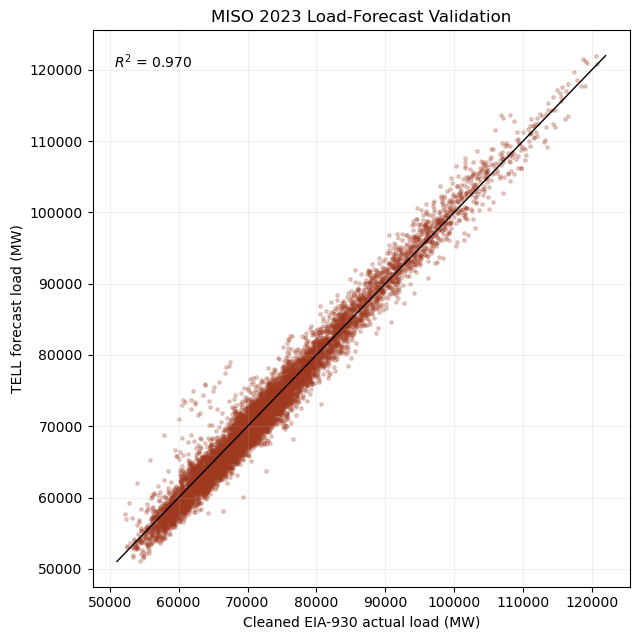

In [13]:
scatter_limits = [
    validation[["actual_load_mw", "forecast_load_mw"]].min().min(),
    validation[["actual_load_mw", "forecast_load_mw"]].max().max(),
]

fig, ax = plt.subplots(figsize=(6.5, 6.5))
ax.scatter(
    validation["actual_load_mw"],
    validation["forecast_load_mw"],
    s=6,
    alpha=0.24,
    color="#9f3a20",
    rasterized=True,
)
ax.plot(scatter_limits, scatter_limits, color="black", linewidth=1)
ax.text(0.04, 0.96, f"$R^2$ = {r2:.3f}", transform=ax.transAxes, va="top")
ax.set_xlabel("Cleaned EIA-930 actual load (MW)")
ax.set_ylabel("TELL forecast load (MW)")
ax.set_title(f"{BA_CODE} {VALIDATION_YEAR} Load-Forecast Validation")
ax.grid(alpha=0.2)
fig.tight_layout()
scatter_path = OUTPUT_DIR / "MISO_2023_tell_actual_vs_forecast_scatter.png"
fig.savefig(scatter_path, dpi=200, bbox_inches="tight")
plt.show()


### January 2023 Load Time Series

Plot one readable month in local Central time using the same actual-versus-modeled load style as the MISO wind, solar, and load validation notebook.


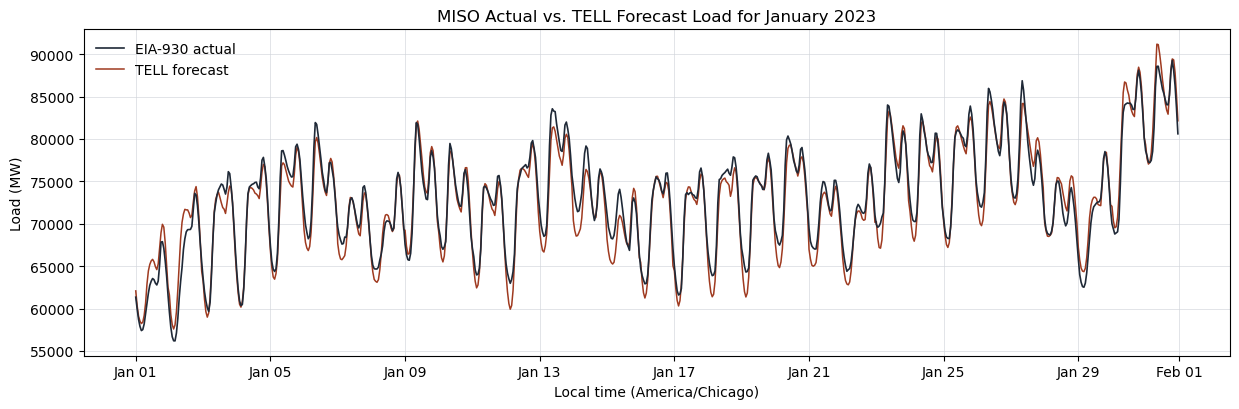

In [14]:
validation_local = validation.assign(
    time_local=validation["time_utc"].dt.tz_convert(LOCAL_TIMEZONE)
)
january_validation = validation_local.loc[
    validation_local["time_local"].dt.year.eq(VALIDATION_YEAR)
    & validation_local["time_local"].dt.month.eq(1)
]

fig, ax = plt.subplots(figsize=(12.5, 4.2))
ax.plot(
    january_validation["time_local"],
    january_validation["actual_load_mw"],
    color="#1f2937",
    linewidth=1.2,
    label="EIA-930 actual",
    zorder=3,
)
ax.plot(
    january_validation["time_local"],
    january_validation["forecast_load_mw"],
    color="#9f3a20",
    linewidth=1.1,
    label="TELL forecast",
)
ax.set_ylabel("Load (MW)")
ax.set_xlabel(f"Local time ({LOCAL_TIMEZONE})")
ax.set_title(f"{BA_CODE} Actual vs. TELL Forecast Load for January 2023")
ax.grid(True, color="#d1d5db", linewidth=0.7, alpha=0.65)
ax.legend(loc="upper left", frameon=False)
ax.xaxis.set_major_locator(
    mdates.DayLocator(bymonthday=range(1, 32, 4), tz=LOCAL_TIMEZONE)
)
ax.xaxis.set_major_formatter(
    mdates.DateFormatter("%b %d", tz=LOCAL_TIMEZONE)
)
fig.tight_layout()
timeseries_path = OUTPUT_DIR / "MISO_20230101_20230131_tell_load_validation.png"
fig.savefig(timeseries_path, dpi=200, bbox_inches="tight")
plt.show()
